# Imports and Setup

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.inspection import permutation_importance

from statsmodels.tsa.ar_model import AutoReg

from xgboost import XGBRegressor

import joblib

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": True,
    "figure.autolayout": True
})

# Define Paths

In [11]:
PROJECT_ROOT = Path(
    r"C:\Users\SherM\OneDrive\Documents\1. Thesis"
)

DATA_PATH = (
    PROJECT_ROOT
    / "Dataset"
    / "Merged_dataset"
    / "master_dataset.parquet"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "Results"
    / "Modeling"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "Figures"
    / "Modeling"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "Models"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Results folder:", RESULTS_DIR)
print("Figure folder:", FIGURE_DIR)
print("Model folder:", MODEL_DIR)

Data path: C:\Users\SherM\OneDrive\Documents\1. Thesis\Dataset\Merged_dataset\master_dataset.parquet
Results folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Results\Modeling
Figure folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\Modeling
Model folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Models


# Load Master Dataset

In [16]:
df = pd.read_parquet(DATA_PATH).sort_index()

print(df.info())
print(df.head())
print(df.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 26112 entries, 2022-01-07 23:00:00+00:00 to 2024-12-30 22:00:00+00:00
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_ahead_price       26112 non-null  float64
 1   lag_1                 26112 non-null  float64
 2   lag_24                26112 non-null  float64
 3   lag_168               26112 non-null  float64
 4   rolling_mean_24       26112 non-null  float64
 5   rolling_std_24        26112 non-null  float64
 6   price_diff            26112 non-null  float64
 7   volatility_24         26112 non-null  float64
 8   hour                  26112 non-null  int32  
 9   day_of_week           26112 non-null  int32  
 10  month                 26112 non-null  int32  
 11  is_weekend            26112 non-null  int64  
 12  hour_sin              26112 non-null  float64
 13  hour_cos              26112 non-null  float64
 14  load                  26112 non-nu

## Convert Index to German Local Time

In [18]:
df_model = df.copy()

# Convert UTC timestamp index to German local time
df_model.index = df_model.index.tz_convert("Europe/Berlin")

print("Index timezone:", df_model.index.tz)
print(df_model.head())

Index timezone: Europe/Berlin
                           day_ahead_price   lag_1  lag_24  lag_168  \
2022-01-08 00:00:00+01:00           164.17  148.32  128.92    50.05   
2022-01-08 01:00:00+01:00           152.83  164.17  118.40    41.33   
2022-01-08 02:00:00+01:00           166.00  152.83  103.01    43.22   
2022-01-08 03:00:00+01:00           160.86  166.00  101.91    45.46   
2022-01-08 04:00:00+01:00           160.00  160.86  101.98    37.67   

                           rolling_mean_24  rolling_std_24  price_diff  \
2022-01-08 00:00:00+01:00       168.649583       44.112352       15.85   
2022-01-08 01:00:00+01:00       170.084167       42.951710      -11.34   
2022-01-08 02:00:00+01:00       172.708750       40.531228       13.17   
2022-01-08 03:00:00+01:00       175.165000       37.744614       -5.14   
2022-01-08 04:00:00+01:00       177.582500       34.578678       -0.86   

                           volatility_24  hour  day_of_week  ...      load  \
2022-01-08 00:00:00+

## Recreate Leakage-Safe Features

In [23]:
df["price_roll_mean_24"] = df["day_ahead_price"].shift(1).rolling(24).mean()

In [25]:
target_col = "day_ahead_price"

# =========================
# PRICE LAG FEATURES
# =========================

df_model["price_lag_1"] = df_model[target_col].shift(1)
df_model["price_lag_24"] = df_model[target_col].shift(24)
df_model["price_lag_48"] = df_model[target_col].shift(48)
df_model["price_lag_168"] = df_model[target_col].shift(168)

# =========================
# LEAKAGE-SAFE PRICE ROLLING FEATURES
# =========================

df_model["price_roll_mean_24"] = (
    df_model[target_col]
    .shift(1)
    .rolling(24)
    .mean()
)

df_model["price_roll_std_24"] = (
    df_model[target_col]
    .shift(1)
    .rolling(24)
    .std()
)

df_model["price_roll_mean_168"] = (
    df_model[target_col]
    .shift(1)
    .rolling(168)
    .mean()
)

# Price change using only past information
df_model["price_diff_lag_1"] = (
    df_model[target_col]
    .diff()
    .shift(1)
)

df_model["price_volatility_24"] = (
    df_model[target_col]
    .diff()
    .shift(1)
    .rolling(24)
    .std()
)

## Create Temporal Features

In [28]:
df_model["hour"] = df_model.index.hour
df_model["day_of_week"] = df_model.index.dayofweek
df_model["month"] = df_model.index.month
df_model["is_weekend"] = (df_model["day_of_week"] >= 5).astype(int)

# Cyclical encoding
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["day_sin"] = np.sin(2 * np.pi * df_model["day_of_week"] / 7)
df_model["day_cos"] = np.cos(2 * np.pi * df_model["day_of_week"] / 7)

df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

## Create Load and Renewable Features

In [31]:
# =========================
# LOAD FEATURES
# =========================

df_model["load_lag_24"] = df_model["load"].shift(24)
df_model["load_lag_168"] = df_model["load"].shift(168)

df_model["load_roll_mean_24"] = (
    df_model["load"]
    .shift(1)
    .rolling(24)
    .mean()
)

df_model["load_ramp_lag_1"] = (
    df_model["load"]
    .diff()
    .shift(1)
)

# =========================
# RENEWABLE FEATURES
# =========================

df_model["wind_lag_24"] = df_model["wind_generation"].shift(24)
df_model["wind_lag_168"] = df_model["wind_generation"].shift(168)

df_model["solar_lag_24"] = df_model["solar_generation"].shift(24)
df_model["solar_lag_168"] = df_model["solar_generation"].shift(168)

df_model["wind_roll_mean_24"] = (
    df_model["wind_generation"]
    .shift(1)
    .rolling(24)
    .mean()
)

df_model["solar_roll_mean_24"] = (
    df_model["solar_generation"]
    .shift(1)
    .rolling(24)
    .mean()
)

df_model["wind_ramp_lag_1"] = (
    df_model["wind_generation"]
    .diff()
    .shift(1)
)

df_model["solar_ramp_lag_1"] = (
    df_model["solar_generation"]
    .diff()
    .shift(1)
)

# Leakage-safe renewable share from lagged values
df_model["renewable_share_lag_24"] = (
    (
        df_model["wind_generation"].shift(24)
        + df_model["solar_generation"].shift(24)
    )
    / df_model["load"].shift(24)
)

## Select Features for Training

In [34]:
feature_cols = [
    # Price memory
    "price_lag_1",
    "price_lag_24",
    "price_lag_48",
    "price_lag_168",
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_mean_168",
    "price_diff_lag_1",
    "price_volatility_24",

    # Temporal features
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",

    # Load features
    "load_lag_24",
    "load_lag_168",
    "load_roll_mean_24",
    "load_ramp_lag_1",

    # Renewable features
    "wind_lag_24",
    "wind_lag_168",
    "solar_lag_24",
    "solar_lag_168",
    "wind_roll_mean_24",
    "solar_roll_mean_24",
    "wind_ramp_lag_1",
    "solar_ramp_lag_1",
    "renewable_share_lag_24"
]

# Keep only existing columns
feature_cols = [col for col in feature_cols if col in df_model.columns]

model_data = df_model[[target_col] + feature_cols].dropna()

print("Model dataset shape:", model_data.shape)
print("Number of features:", len(feature_cols))
print(feature_cols)

Model dataset shape: (25944, 33)
Number of features: 32
['price_lag_1', 'price_lag_24', 'price_lag_48', 'price_lag_168', 'price_roll_mean_24', 'price_roll_std_24', 'price_roll_mean_168', 'price_diff_lag_1', 'price_volatility_24', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'load_lag_24', 'load_lag_168', 'load_roll_mean_24', 'load_ramp_lag_1', 'wind_lag_24', 'wind_lag_168', 'solar_lag_24', 'solar_lag_168', 'wind_roll_mean_24', 'solar_roll_mean_24', 'wind_ramp_lag_1', 'solar_ramp_lag_1', 'renewable_share_lag_24']


# Train-Test Split

In [37]:
split_date = "2024-01-01"

train_data = model_data[model_data.index < split_date].copy()
test_data = model_data[model_data.index >= split_date].copy()

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("Training period:")
print(X_train.index.min(), "to", X_train.index.max())
print("Training shape:", X_train.shape)

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())
print("Testing shape:", X_test.shape)

Training period:
2022-01-15 00:00:00+01:00 to 2023-12-31 23:00:00+01:00
Training shape: (17184, 32)

Testing period:
2024-01-01 00:00:00+01:00 to 2024-12-30 23:00:00+01:00
Testing shape: (8760, 32)


## Evaluation Functions

In [40]:
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100


def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    smape_value = smape(y_true, y_pred)
    wape_value = wape(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "WAPE (%)": wape_value,
        "R2": r2
    }

## Baseline Models

### Naive Model: Same Hour Yesterday

In [43]:
results = []

y_pred_naive_24 = X_test["price_lag_24"]

results.append(
    evaluate_model(
        "Naive: same hour previous day",
        y_test,
        y_pred_naive_24
    )
)

### Rolling Mean Baseline

In [47]:
y_pred_rolling_24 = X_test["price_roll_mean_24"]

results.append(
    evaluate_model(
        "Rolling mean 24h baseline",
        y_test,
        y_pred_rolling_24
    )
)

# Statistical Baseline: Autoregressive Model

In [50]:
# AutoReg uses only the target series
ar_train = y_train.copy()

ar_model = AutoReg(
    ar_train,
    lags=[1, 24, 168],
    old_names=False
)

ar_result = ar_model.fit()

print(ar_result.summary())

                             AutoReg Model Results                             
Dep. Variable:         day_ahead_price   No. Observations:                17184
Model:             Restr. AutoReg(168)   Log Likelihood              -78620.927
Method:                Conditional MLE   S.D. of innovations             24.569
Date:                 Tue, 16 Jun 2026   AIC                         157251.854
Time:                         11:36:58   BIC                         157290.563
Sample:                     01-22-2022   HQIC                        157264.618
                          - 12-31-2023                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.5310      0.324     -1.640      0.101      -1.166       0.104
day_ahead_price.L1       0.8719      0.003    281.713      0.000       0.866       0.878
day_

In [52]:
# Forecast test period
ar_forecast = ar_result.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    dynamic=False
)

ar_forecast.index = y_test.index

results.append(
    evaluate_model(
        "Autoregressive statistical baseline",
        y_test,
        ar_forecast
    )
)

# Random Forest Model

In [55]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

# XGBoost Model

In [58]:
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb
    )
)

# Compare Model Performance

In [61]:
results_df = (
    pd.DataFrame(results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

results_df

,model,MAE,RMSE,sMAPE (%),WAPE (%),R2
0,XGBoost,7.485302,14.757892,20.592651,9.385180,0.921798
1,Random Forest,7.710234,15.564141,19.950935,9.667204,0.913020
2,Naive: same hour previous day,27.848379,44.348272,52.677948,34.916704,0.293809
3,Rolling mean 24h baseline,28.382767,42.719376,47.580254,35.586727,0.344733
4,Autoregressive statistical baseline,597.357057,762.117966,198.382328,748.974988,-207.551350


In [63]:
results_df.to_csv(
    RESULTS_DIR / "model_comparison_results.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


# Save Predictions

In [66]:
predictions = pd.DataFrame(
    {
        "actual_price": y_test,
        "naive_24": y_pred_naive_24,
        "rolling_mean_24": y_pred_rolling_24,
        "autoregressive": ar_forecast,
        "random_forest": y_pred_rf,
        "xgboost": y_pred_xgb
    },
    index=y_test.index
)

predictions.to_csv(
    RESULTS_DIR / "model_predictions_test_set.csv"
)

predictions.head()

,actual_price,naive_24,rolling_mean_24,autoregressive,random_forest,xgboost
2024-01-01 00:00:00+01:00,0.10,28.25,9.557500,3.861410,3.737650,2.829679
2024-01-01 01:00:00+01:00,0.01,13.27,8.384583,3.534134,1.454200,1.412234
2024-01-01 02:00:00+01:00,0.00,4.00,7.832083,2.417110,2.828029,1.812522
2024-01-01 03:00:00+01:00,-0.01,0.31,7.665417,1.049796,2.842356,-0.641444
2024-01-01 04:00:00+01:00,-0.03,0.58,7.652083,-0.158092,2.660372,3.737674


# Plot Model Comparison

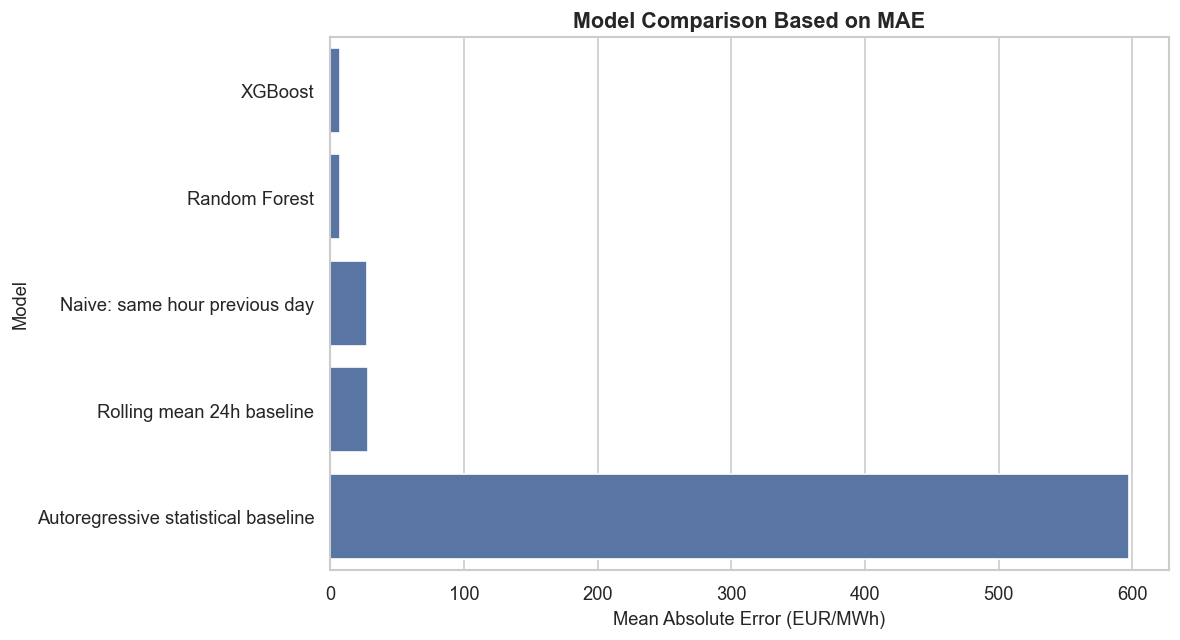

In [69]:
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=results_df,
    x="MAE",
    y="model",
    ax=ax
)

ax.set_title("Model Comparison Based on MAE")
ax.set_xlabel("Mean Absolute Error (EUR/MWh)")
ax.set_ylabel("Model")

plt.savefig(
    FIGURE_DIR / "model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Actual vs Predicted Prices

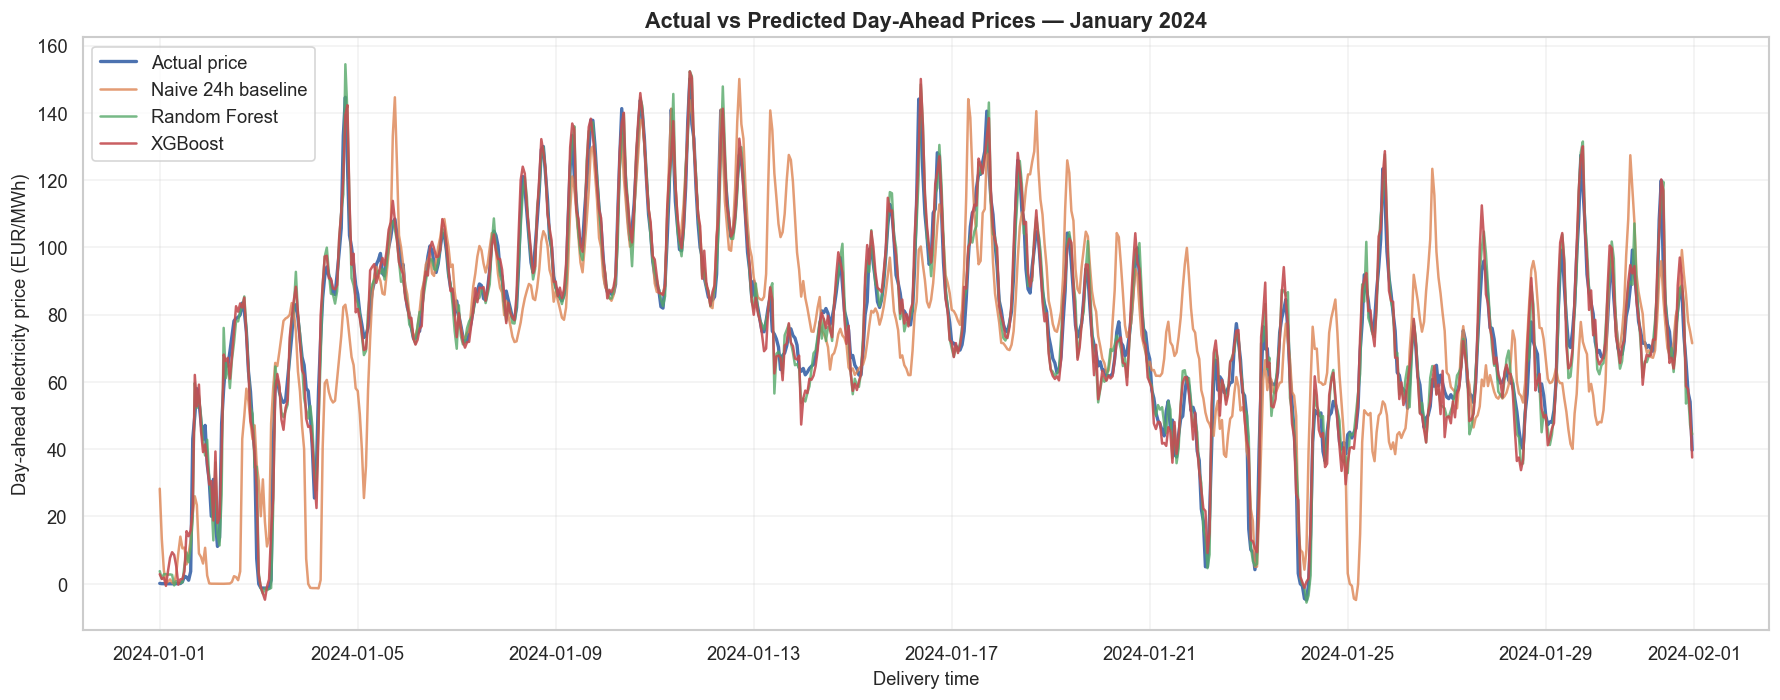

In [72]:
plot_start = "2024-01-01"
plot_end = "2024-01-31"

plot_data = predictions.loc[plot_start:plot_end]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    plot_data.index,
    plot_data["actual_price"],
    label="Actual price",
    linewidth=2
)

ax.plot(
    plot_data.index,
    plot_data["naive_24"],
    label="Naive 24h baseline",
    alpha=0.8
)

ax.plot(
    plot_data.index,
    plot_data["random_forest"],
    label="Random Forest",
    alpha=0.8
)

ax.plot(
    plot_data.index,
    plot_data["xgboost"],
    label="XGBoost",
    alpha=0.9
)

ax.set_title("Actual vs Predicted Day-Ahead Prices — January 2024")
ax.set_xlabel("Delivery time")
ax.set_ylabel("Day-ahead electricity price (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.25)

plt.savefig(
    FIGURE_DIR / "actual_vs_predicted_january_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Residual Analysis

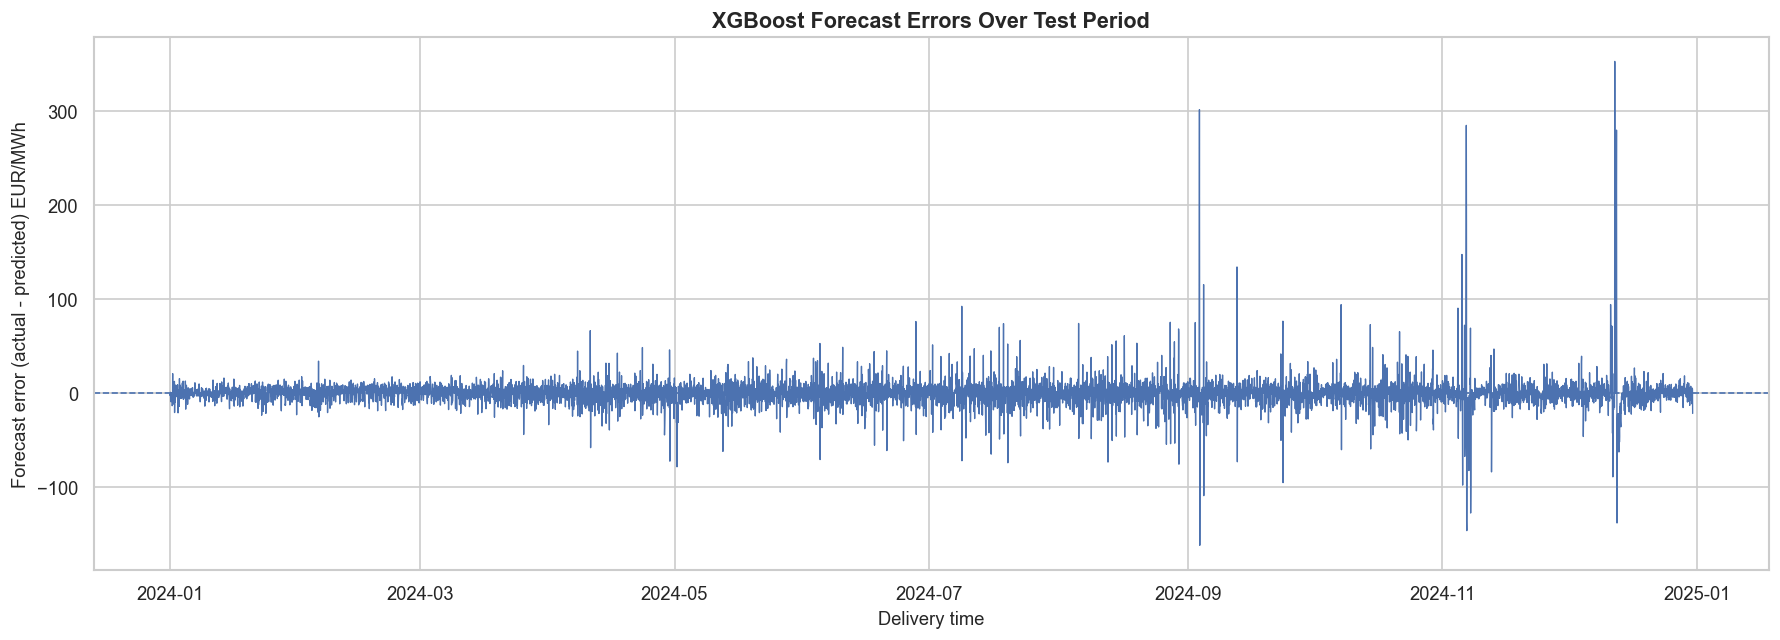

In [75]:
predictions["xgboost_error"] = (
    predictions["actual_price"]
    - predictions["xgboost"]
)

fig, ax = plt.subplots(figsize=(15, 5.5))

ax.plot(
    predictions.index,
    predictions["xgboost_error"],
    linewidth=0.8
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("XGBoost Forecast Errors Over Test Period")
ax.set_xlabel("Delivery time")
ax.set_ylabel("Forecast error (actual - predicted) EUR/MWh")

plt.savefig(
    FIGURE_DIR / "xgboost_forecast_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

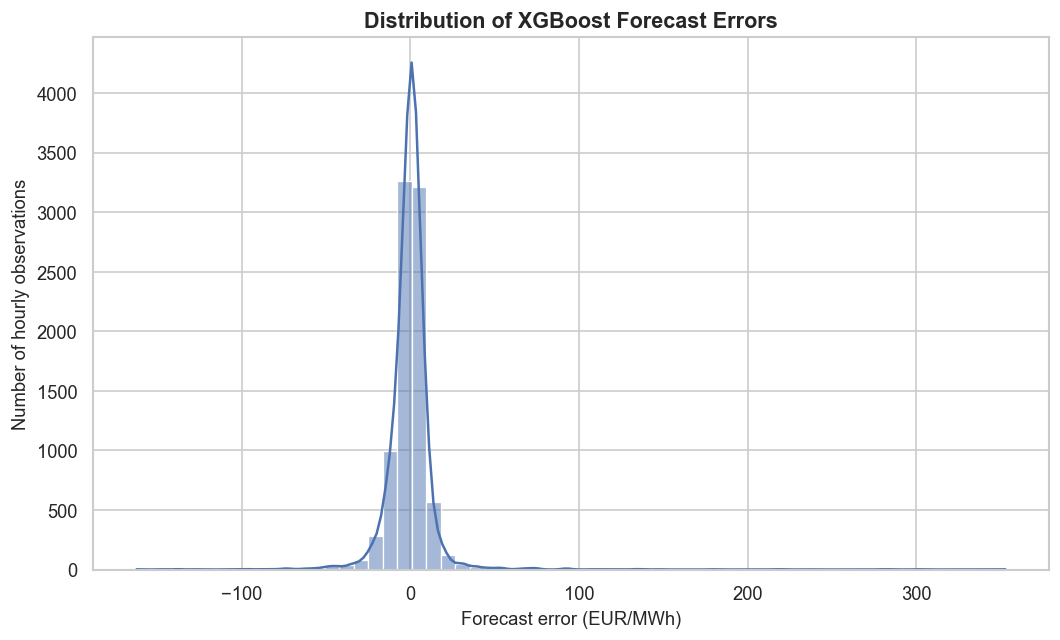

In [77]:
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(
    predictions["xgboost_error"],
    bins=60,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of XGBoost Forecast Errors")
ax.set_xlabel("Forecast error (EUR/MWh)")
ax.set_ylabel("Number of hourly observations")

plt.savefig(
    FIGURE_DIR / "xgboost_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# XGBoost Feature Importance

In [80]:
xgb_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_
    }
).sort_values(
    "importance",
    ascending=False
)

xgb_importance.to_csv(
    RESULTS_DIR / "xgboost_feature_importance.csv",
    index=False
)

xgb_importance.head(20)

,feature,importance
0,price_lag_1,0.650692
4,price_roll_mean_24,0.221504
1,price_lag_24,0.022953
7,price_diff_lag_1,0.014956
6,price_roll_mean_168,0.012615
13,hour_sin,0.010557
30,solar_ramp_lag_1,0.008286
3,price_lag_168,0.005165
14,hour_cos,0.004998
12,is_weekend,0.004692


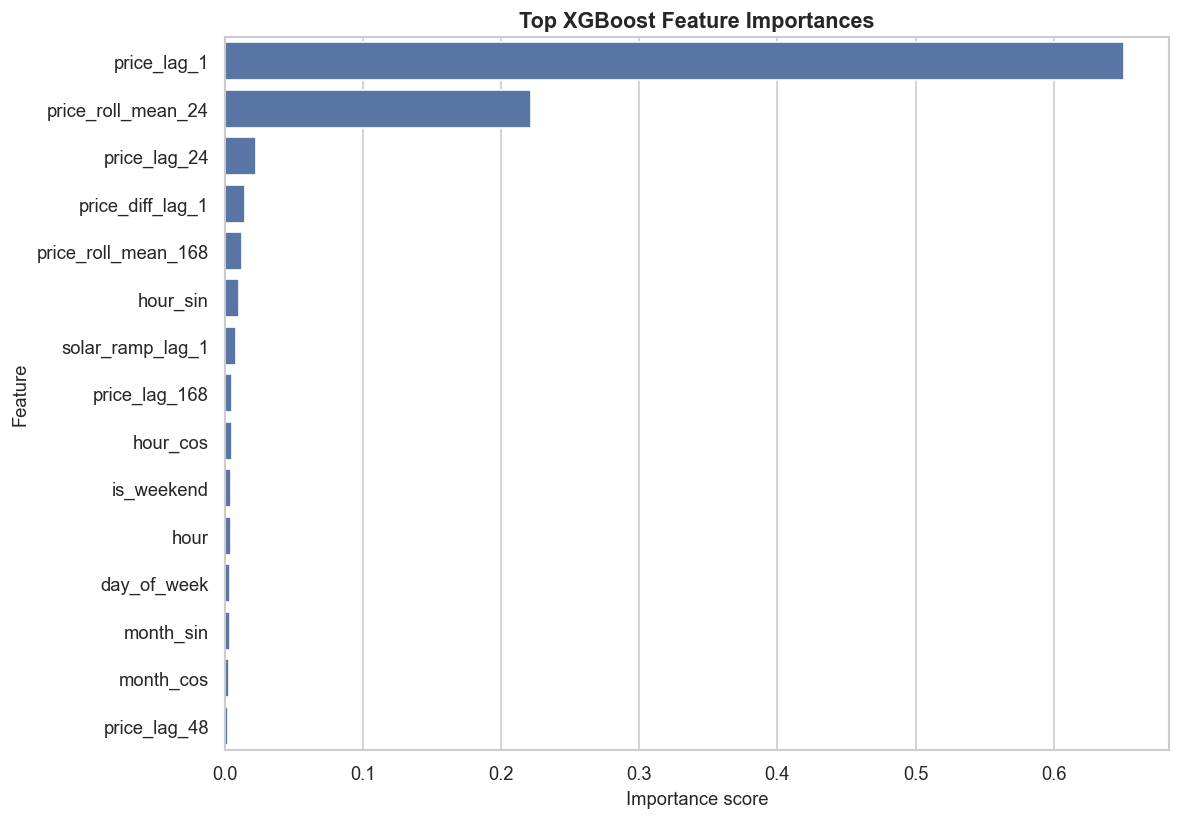

In [82]:
top_n = 15

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=xgb_importance.head(top_n),
    x="importance",
    y="feature",
    ax=ax
)

ax.set_title("Top XGBoost Feature Importances")
ax.set_xlabel("Importance score")
ax.set_ylabel("Feature")

plt.savefig(
    FIGURE_DIR / "xgboost_feature_importance_top15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Permutation Importance

In [85]:
perm_result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }
).sort_values(
    "importance_mean",
    ascending=False
)

perm_importance.to_csv(
    RESULTS_DIR / "xgboost_permutation_importance.csv",
    index=False
)

perm_importance.head(20)

,feature,importance_mean,importance_std
0,price_lag_1,38.694326,0.416610
30,solar_ramp_lag_1,3.714727,0.036291
7,price_diff_lag_1,1.230525,0.044518
13,hour_sin,0.726355,0.025167
14,hour_cos,0.483817,0.007890
9,hour,0.419816,0.013230
29,wind_ramp_lag_1,0.332007,0.014708
4,price_roll_mean_24,0.272047,0.007750
22,load_ramp_lag_1,0.141756,0.007018
10,day_of_week,0.117935,0.004806


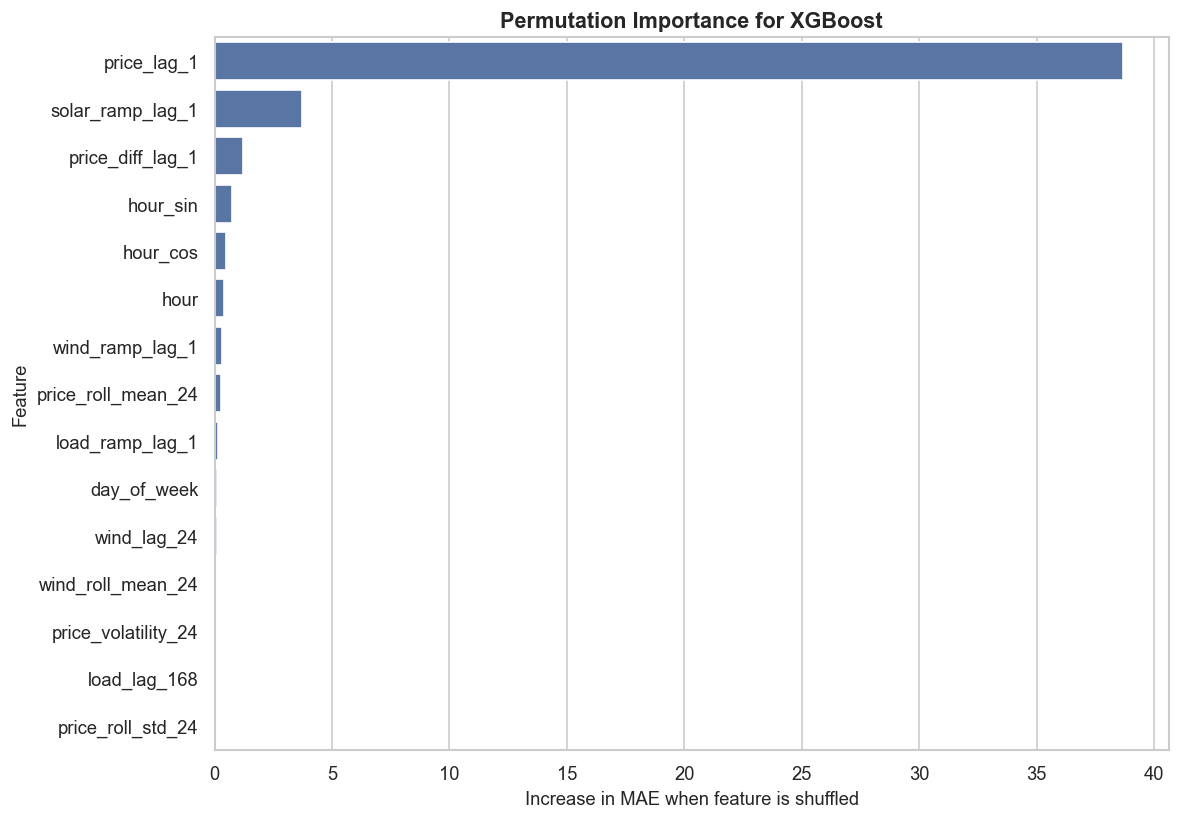

In [87]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=perm_importance.head(15),
    x="importance_mean",
    y="feature",
    ax=ax
)

ax.set_title("Permutation Importance for XGBoost")
ax.set_xlabel("Increase in MAE when feature is shuffled")
ax.set_ylabel("Feature")

plt.savefig(
    FIGURE_DIR / "xgboost_permutation_importance_top15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save Trained Models

In [90]:
joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest_model.pkl"
)

joblib.dump(
    xgb_model,
    MODEL_DIR / "xgboost_model.pkl"
)

joblib.dump(
    ar_result,
    MODEL_DIR / "autoregressive_model.pkl"
)

print("Models saved successfully.")

Models saved successfully.
